In [362]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

os.makedirs("images", exist_ok=True)

import os
os.chdir(r"C:\Users\facua\OneDrive\Desktop\worldcup2022_data_analysis")
print(os.getcwd())

print("ok")

C:\Users\facua\OneDrive\Desktop\worldcup2022_data_analysis
ok


In [363]:
df_2022 = pd.read_csv(r"C:\Users\facua\OneDrive\Desktop\worldcup2022_data_analysis\data\raw\worldcup_2022\worldcup_2022.csv")
df_2022.head()

,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,penalties scored team1,penalties scored team2,goal preventions team1,goal preventions team2,own goals team1,own goals team2,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2
0,QATAR,ECUADOR,42%,50%,8%,0,2,20 NOV 2022,17 : 00,Group A,...,0,1,6,5,0,0,52,72,256,279
1,ENGLAND,IRAN,72%,19%,9%,6,2,21 NOV 2022,14 : 00,Group B,...,0,1,8,13,0,0,63,72,139,416
2,SENEGAL,NETHERLANDS,44%,45%,11%,0,2,21 NOV 2022,17 : 00,Group A,...,0,0,9,15,0,0,63,73,263,251
3,UNITED STATES,WALES,51%,39%,10%,1,1,21 NOV 2022,20 : 00,Group B,...,0,1,7,7,0,0,81,72,242,292
4,ARGENTINA,SAUDI ARABIA,64%,24%,12%,1,2,22 NOV 2022,11 : 00,Group C,...,1,0,4,14,0,0,65,80,163,361


In [364]:
print("\n2022:")
print(df_2022.columns)


2022:
Index(['team1', 'team2', 'possession team1', 'possession team2',
       'possession in contest', 'number of goals team1',
       'number of goals team2', 'date', 'hour', 'category',
       'total attempts team1', 'total attempts team2', 'conceded team1',
       'conceded team2', 'goal inside the penalty area team1',
       'goal inside the penalty area team2',
       'goal outside the penalty area team1',
       'goal outside the penalty area team2', 'assists team1', 'assists team2',
       'on target attempts team1', 'on target attempts team2',
       'off target attempts team1', 'off target attempts team2',
       'attempts inside the penalty area team1',
       'attempts inside the penalty area  team2',
       'attempts outside the penalty area  team1',
       'attempts outside the penalty area  team2', 'left channel team1',
       'left channel team2', 'left inside channel team1',
       'left inside channel team2', 'central channel team1',
       'central channel team2', 'r

In [365]:
df_2022.columns = df_2022.columns.str.strip().str.lower()

In [366]:
df_2022["total_goals"] = (
    df_2022["number of goals team1"] + df_2022["number of goals team2"]
)

In [367]:
df_2022["goal_diff"] = (
    df_2022["number of goals team1"] - df_2022["number of goals team2"]
)

In [368]:
## Promedio golespor partido en 2022

In [369]:
df_2022["total_goals"].mean()

np.float64(2.6875)

Partidos mas goleadores

In [370]:
df_2022.sort_values("total_goals", ascending=False).head()

,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,goal preventions team1,goal preventions team2,own goals team1,own goals team2,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2,total_goals,goal_diff
1,ENGLAND,IRAN,72%,19%,9%,6,2,21 NOV 2022,14 : 00,Group B,...,8,13,0,0,63,72,139,416,8,4
10,SPAIN,COSTA RICA,74%,17%,9%,7,0,23 NOV 2022,17 : 00,Group E,...,0,17,0,0,46,76,185,585,7,7
55,PORTUGAL,SWITZERLAND,43%,48%,9%,6,1,06 DEC 2022,20 : 00,Round of 16,...,10,15,0,0,71,54,357,240,7,5
63,ARGENTINA,FRANCE,46%,40%,14%,3,3,18 DEC 2022,16 : 00,Final,...,11,21,0,0,87,104,280,409,6,0
28,CAMEROON,SERBIA,38%,49%,13%,3,3,28 NOV 2022,11 : 00,Group G,...,16,13,0,0,83,81,285,234,6,0


Total goles por Pais

In [371]:
team1 = df_2022[["team1", "number of goals team1"]].rename(
    columns={"team1":"team", "number of goals team1":"goals"}
)

team2 = df_2022[["team2", "number of goals team2"]].rename(
    columns={"team2":"team", "number of goals team2":"goals"}
)

df_teams = pd.concat([team1, team2])

In [372]:
df_teams.groupby("team")["goals"].sum().sort_values(ascending=False)

team
FRANCE            16
ARGENTINA         15
ENGLAND           13
PORTUGAL          12
NETHERLANDS       10
SPAIN              9
BRAZIL             8
CROATIA            8
GERMANY            6
MOROCCO            6
JAPAN              5
SWITZERLAND        5
SERBIA             5
SENEGAL            5
KOREA REPUBLIC     5
GHANA              5
IRAN               4
AUSTRALIA          4
ECUADOR            4
CAMEROON           4
UNITED STATES      3
COSTA RICA         3
SAUDI ARABIA       3
POLAND             3
CANADA             2
MEXICO             2
URUGUAY            2
QATAR              1
DENMARK            1
BELGIUM            1
TUNISIA            1
WALES              1
Name: goals, dtype: int64

goles totales + partidos jugados

In [373]:
games_played = df_teams.groupby("team").size()

In [374]:
total_goals = df_teams.groupby("team")["goals"].sum()

In [375]:
df_stats = pd.DataFrame({
    "goals_total": total_goals,
    "games_played": games_played,
})

In [376]:
df_stats["goals_per_game"] = df_stats["goals_total"] / df_stats["games_played"]

In [377]:
df_stats.sort_values("goals_per_game", ascending=False)

,goals_total,games_played,goals_per_game
team,,,
ENGLAND,13,5,2.600000
PORTUGAL,12,5,2.400000
FRANCE,16,7,2.285714
SPAIN,9,4,2.250000
ARGENTINA,15,7,2.142857
NETHERLANDS,10,5,2.000000
GERMANY,6,3,2.000000
SERBIA,5,3,1.666667
GHANA,5,3,1.666667


En el Mundial 2022, la eficiencia ofensiva no siempre se correlaciona con el rendimiento final del torneo”

Top 10 equipos

In [378]:
df_stats.sort_values("goals_per_game", ascending=False).head(10)

,goals_total,games_played,goals_per_game
team,,,
ENGLAND,13,5,2.600000
PORTUGAL,12,5,2.400000
FRANCE,16,7,2.285714
SPAIN,9,4,2.250000
ARGENTINA,15,7,2.142857
NETHERLANDS,10,5,2.000000
GERMANY,6,3,2.000000
SERBIA,5,3,1.666667
GHANA,5,3,1.666667


Filtrar partidos de Argentina

In [379]:
df_2022["team1"].unique()

array(['QATAR', 'ENGLAND', 'SENEGAL', 'UNITED STATES', 'ARGENTINA',
       'DENMARK', 'MEXICO', 'FRANCE', 'MOROCCO', 'GERMANY', 'SPAIN',
       'BELGIUM', 'SWITZERLAND', 'URUGUAY', 'PORTUGAL', 'BRAZIL', 'WALES',
       'NETHERLANDS', 'TUNISIA', 'POLAND', 'JAPAN', 'CROATIA', 'CAMEROON',
       'KOREA REPUBLIC', 'ECUADOR', 'IRAN', 'AUSTRALIA', 'SAUDI ARABIA',
       'CANADA', 'COSTA RICA', 'GHANA', 'SERBIA'], dtype=object)

In [380]:
df_2022["team2"].unique()

array(['ECUADOR', 'IRAN', 'NETHERLANDS', 'WALES', 'SAUDI ARABIA',
       'TUNISIA', 'POLAND', 'AUSTRALIA', 'CROATIA', 'JAPAN', 'COSTA RICA',
       'CANADA', 'CAMEROON', 'KOREA REPUBLIC', 'GHANA', 'SERBIA',
       'SENEGAL', 'UNITED STATES', 'DENMARK', 'MEXICO', 'MOROCCO',
       'GERMANY', 'SWITZERLAND', 'URUGUAY', 'QATAR', 'ENGLAND', 'FRANCE',
       'ARGENTINA', 'BELGIUM', 'SPAIN', 'PORTUGAL', 'BRAZIL'],
      dtype=object)

# ANÁLISIS 1 — Argentina campeón (rendimiento)

Filtrar partidos de Argentina

In [381]:
arg_matches = df_2022[
    (df_2022["team1"] == "ARGENTINA") |
    (df_2022["team2"] == "ARGENTINA")
].copy()

Crear columna de goles

In [382]:
arg_matches["arg_goals"] = arg_matches.apply(
    lambda row: row["number of goals team1"] if row["team1"] == "ARGENTINA"
    else row["number of goals team2"],
    axis=1
)

Chequeo rápido

In [383]:
arg_matches[["team1", "team2", "arg_goals"]].head()

,team1,team2,arg_goals
4,ARGENTINA,SAUDI ARABIA,1
23,ARGENTINA,MEXICO,2
38,POLAND,ARGENTINA,2
49,ARGENTINA,AUSTRALIA,2
57,NETHERLANDS,ARGENTINA,2


Resultado

In [384]:
arg_matches["arg_goals"].sum()

np.int64(15)

In [385]:
df_2022.head()

,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,goal preventions team1,goal preventions team2,own goals team1,own goals team2,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2,total_goals,goal_diff
0,QATAR,ECUADOR,42%,50%,8%,0,2,20 NOV 2022,17 : 00,Group A,...,6,5,0,0,52,72,256,279,2,-2
1,ENGLAND,IRAN,72%,19%,9%,6,2,21 NOV 2022,14 : 00,Group B,...,8,13,0,0,63,72,139,416,8,4
2,SENEGAL,NETHERLANDS,44%,45%,11%,0,2,21 NOV 2022,17 : 00,Group A,...,9,15,0,0,63,73,263,251,2,-2
3,UNITED STATES,WALES,51%,39%,10%,1,1,21 NOV 2022,20 : 00,Group B,...,7,7,0,0,81,72,242,292,2,0
4,ARGENTINA,SAUDI ARABIA,64%,24%,12%,1,2,22 NOV 2022,11 : 00,Group C,...,4,14,0,0,65,80,163,361,3,-1


In [386]:
for col in df_2022.columns:
    print(col)

team1
team2
possession team1
possession team2
possession in contest
number of goals team1
number of goals team2
date
hour
category
total attempts team1
total attempts team2
conceded team1
conceded team2
goal inside the penalty area team1
goal inside the penalty area team2
goal outside the penalty area team1
goal outside the penalty area team2
assists team1
assists team2
on target attempts team1
on target attempts team2
off target attempts team1
off target attempts team2
attempts inside the penalty area team1
attempts inside the penalty area  team2
attempts outside the penalty area  team1
attempts outside the penalty area  team2
left channel team1
left channel team2
left inside channel team1
left inside channel team2
central channel team1
central channel team2
right inside channel team1
right inside channel team2
right channel team1
right channel team2
total offers to receive team1
total offers to receive team2
inbehind offers to receive team1
inbehind offers to receive team2
inbetween 

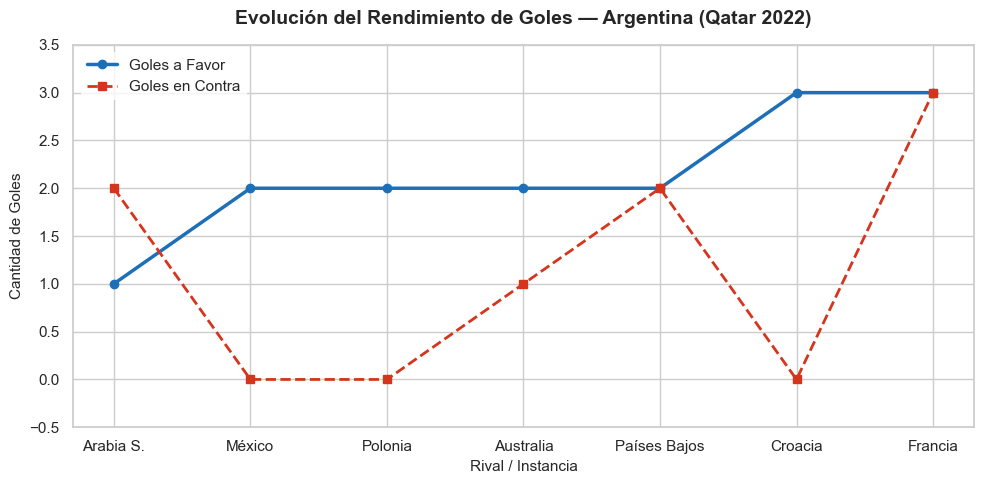

In [387]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos un estilo limpio y profesional
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Asumiendo que tu DataFrame de Argentina se llama 'df_argentina'
# Si no, podés usar las listas directas basadas en tus datos:
partidos = ['Arabia S.', 'México', 'Polonia', 'Australia', 'Países Bajos', 'Croacia', 'Francia']
goles_favor = [1, 2, 2, 2, 2, 3, 3]
goles_contra = [2, 0, 0, 1, 2, 0, 3]

plt.plot(partidos, goles_favor, marker='o', color='#1d70b8', linewidth=2.5, label='Goles a Favor')
plt.plot(partidos, goles_contra, marker='s', color='#d4351c', linewidth=2, linestyle='--', label='Goles en Contra')

plt.title('Evolución del Rendimiento de Goles — Argentina (Qatar 2022)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Rival / Instancia', fontsize=11)
plt.ylabel('Cantidad de Goles', fontsize=11)
plt.ylim(-0.5, 3.5)
plt.legend(frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

## ANÁLISIS 2 — Dominio del juego (posesión)

In [388]:
df_2022["possession team1"] = (
    df_2022["possession team1"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

df_2022["possession team2"] = (
    df_2022["possession team2"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

In [389]:
df_2022["possession team1"].dtype

dtype('float64')

In [390]:
df_2022["possession team2"].dtype

dtype('float64')

In [391]:
df_2022[
    [
        "team1",
        "team2",
        "possession team1",
        "possession team2",
        "category"
    ]
].head(64)

,team1,team2,possession team1,possession team2,category
0,QATAR,ECUADOR,42.0,50.0,Group A
1,ENGLAND,IRAN,72.0,19.0,Group B
2,SENEGAL,NETHERLANDS,44.0,45.0,Group A
3,UNITED STATES,WALES,51.0,39.0,Group B
4,ARGENTINA,SAUDI ARABIA,64.0,24.0,Group C
...,...,...,...,...,...
59,ENGLAND,FRANCE,54.0,36.0,Quarter-final
60,ARGENTINA,CROATIA,34.0,54.0,Semi-final
61,FRANCE,MOROCCO,34.0,55.0,Semi-final
62,CROATIA,MOROCCO,45.0,45.0,Play-off for third place


In [392]:
arg_matches = df_2022[
    (df_2022["team1"] == "ARGENTINA") |
    (df_2022["team2"] == "ARGENTINA")
]

arg_matches[
    [
        "team1",
        "team2",
        "possession team1",
        "possession team2",
        "number of goals team1",
        "number of goals team2",
        "category"
    ]
]

,team1,team2,possession team1,possession team2,number of goals team1,number of goals team2,category
4,ARGENTINA,SAUDI ARABIA,64.0,24.0,1,2,Group C
23,ARGENTINA,MEXICO,50.0,36.0,2,0,Group C
38,POLAND,ARGENTINA,24.0,67.0,0,2,Group C
49,ARGENTINA,AUSTRALIA,53.0,35.0,2,1,Round of 16
57,NETHERLANDS,ARGENTINA,45.0,44.0,2,2,Quarter-final
60,ARGENTINA,CROATIA,34.0,54.0,3,0,Semi-final
63,ARGENTINA,FRANCE,46.0,40.0,3,3,Final


In [393]:
arg_matches = df_2022[
    (df_2022["team1"] == "ARGENTINA") |
    (df_2022["team2"] == "ARGENTINA")
].copy()

In [394]:
arg_matches["arg_possession"] = arg_matches.apply(
    lambda row: row["possession team1"]
    if row["team1"] == "ARGENTINA"
    else row["possession team2"],
    axis=1
)

In [395]:
arg_matches[["team1", "team2", "arg_possession"]]

,team1,team2,arg_possession
4,ARGENTINA,SAUDI ARABIA,64.0
23,ARGENTINA,MEXICO,50.0
38,POLAND,ARGENTINA,67.0
49,ARGENTINA,AUSTRALIA,53.0
57,NETHERLANDS,ARGENTINA,44.0
60,ARGENTINA,CROATIA,34.0
63,ARGENTINA,FRANCE,46.0


In [396]:
arg_matches["arg_possession"].mean()

np.float64(51.142857142857146)

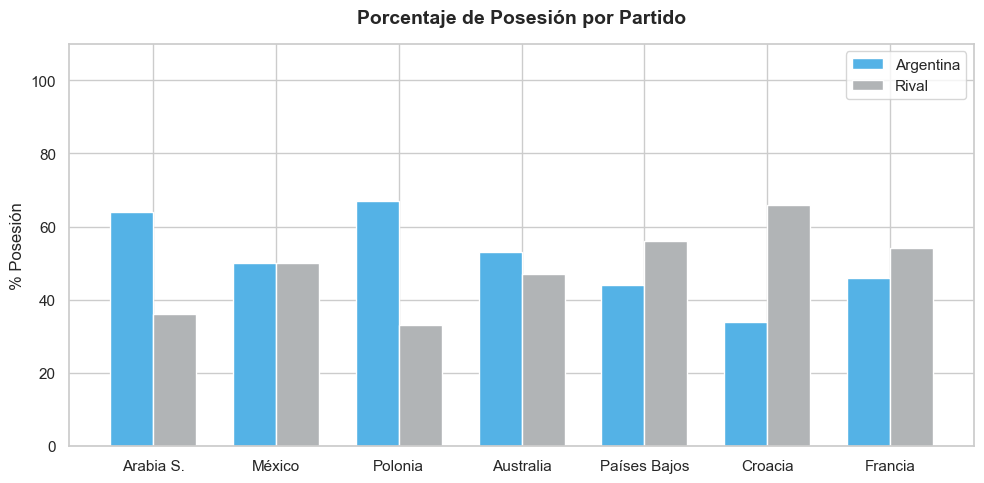

In [452]:
import numpy as np

plt.figure(figsize=(10, 5))

# Datos basados en tu tabla de posesión
rivales = ['Arabia S.', 'México', 'Polonia', 'Australia', 'Países Bajos', 'Croacia', 'Francia']
pos_arg = [64.0, 50.0, 67.0, 53.0, 44.0, 34.0, 46.0]
pos_rival = [36.0, 50.0, 33.0, 47.0, 56.0, 66.0, 54.0] # cálculo del complemento

x = np.arange(len(rivales))
width = 0.35

plt.bar(x - width/2, pos_arg, width, label='Argentina', color='#54b2e6')
plt.bar(x + width/2, pos_rival, width, label='Rival', color='#b1b4b6')

plt.title('Porcentaje de Posesión por Partido', fontsize=14, fontweight='bold', pad=15)
plt.xticks(x, rivales)
plt.ylabel('% Posesión')
plt.ylim(0, 110)
plt.legend(frameon=True)

plt.tight_layout()
plt.savefig("images/posesion_argentina.png", dpi=150, bbox_inches="tight")
plt.show()

## ANÁLISIS 3 — Estilo de juego del campeón

In [398]:
arg_matches["arg_left_channel"] = arg_matches.apply(
    lambda row: row["left channel team1"]
    if row["team1"] == "ARGENTINA"
    else row["left channel team2"],
    axis=1
)

arg_matches["arg_central_channel"] = arg_matches.apply(
    lambda row: row["central channel team1"]
    if row["team1"] == "ARGENTINA"
    else row["central channel team2"],
    axis=1
)

arg_matches["arg_right_channel"] = arg_matches.apply(
    lambda row: row["right channel team1"]
    if row["team1"] == "ARGENTINA"
    else row["right channel team2"],
    axis=1
)

In [399]:
arg_matches[[
    "team1",
    "team2",
    "category",
    "arg_left_channel",
    "arg_central_channel",
    "arg_right_channel"
]]

,team1,team2,category,arg_left_channel,arg_central_channel,arg_right_channel
4,ARGENTINA,SAUDI ARABIA,Group C,12,5,18
23,ARGENTINA,MEXICO,Group C,10,2,12
38,POLAND,ARGENTINA,Group C,25,7,26
49,ARGENTINA,AUSTRALIA,Round of 16,15,11,17
57,NETHERLANDS,ARGENTINA,Quarter-final,7,13,17
60,ARGENTINA,CROATIA,Semi-final,8,7,2
63,ARGENTINA,FRANCE,Final,13,8,9


In [400]:
channels = arg_matches[[
    "arg_left_channel",
    "arg_central_channel",
    "arg_right_channel"
]].sum()

channels

arg_left_channel        90
arg_central_channel     53
arg_right_channel      101
dtype: int64

In [401]:
channels / channels.sum() * 100

arg_left_channel       36.885246
arg_central_channel    21.721311
arg_right_channel      41.393443
dtype: float64

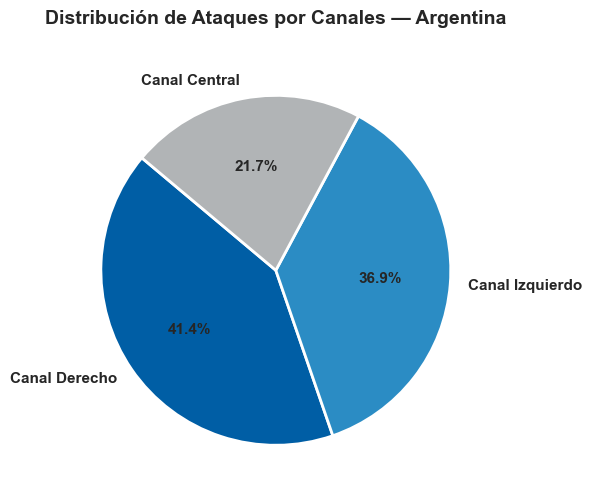

In [402]:
plt.figure(figsize=(6, 6))

canales = ['Canal Derecho', 'Canal Izquierdo', 'Canal Central']
frecuencias = [101, 90, 53]
colores = ['#005ea5', '#2b8cc4', '#b1b4b6']

plt.pie(frecuencias, labels=canales, colors=colores, autopct='%1.1f%%', 
        startangle=140, textprops={'fontsize': 11, 'fontweight': 'bold'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

plt.title('Distribución de Ataques por Canales — Argentina', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## ANÁLISIS 4 — Equipos más ofensivos

In [403]:
df_attack = pd.concat([
    df_2022[["team1", "total attempts team1"]].rename(
        columns={"team1":"team", "total attempts team1":"attempts"}
    ),
    df_2022[["team2", "total attempts team2"]].rename(
        columns={"team2":"team", "total attempts team2":"attempts"}
    )
])


In [404]:
attack_ranking = (
    df_attack
    .groupby("team")["attempts"]
    .mean()
    .sort_values(ascending=False)
)

attack_ranking

team
GERMANY           22.333333
BRAZIL            18.000000
ARGENTINA         14.857143
FRANCE            14.428571
MEXICO            14.000000
SPAIN             12.750000
SENEGAL           12.750000
PORTUGAL          12.400000
KOREA REPUBLIC    12.250000
ENGLAND           12.000000
DENMARK           11.666667
CANADA            11.666667
IRAN              11.666667
CROATIA           11.571429
UNITED STATES     11.500000
BELGIUM           11.333333
URUGUAY           10.666667
JAPAN             10.500000
SERBIA            10.333333
TUNISIA            9.666667
SAUDI ARABIA       9.666667
SWITZERLAND        9.000000
CAMEROON           9.000000
ECUADOR            9.000000
MOROCCO            8.714286
GHANA              8.333333
WALES              8.000000
NETHERLANDS        8.000000
POLAND             7.750000
QATAR              7.000000
AUSTRALIA          6.250000
COSTA RICA         4.000000
Name: attempts, dtype: float64

In [405]:
df_attack.groupby("team")["attempts"].sum().sort_values(ascending=False)

team
ARGENTINA         104
FRANCE            101
BRAZIL             90
CROATIA            81
GERMANY            67
PORTUGAL           62
MOROCCO            61
ENGLAND            60
SPAIN              51
SENEGAL            51
KOREA REPUBLIC     49
UNITED STATES      46
JAPAN              42
MEXICO             42
NETHERLANDS        40
SWITZERLAND        36
CANADA             35
IRAN               35
DENMARK            35
BELGIUM            34
URUGUAY            32
SERBIA             31
POLAND             31
TUNISIA            29
SAUDI ARABIA       29
ECUADOR            27
CAMEROON           27
AUSTRALIA          25
GHANA              25
WALES              24
QATAR              21
COSTA RICA         12
Name: attempts, dtype: int64

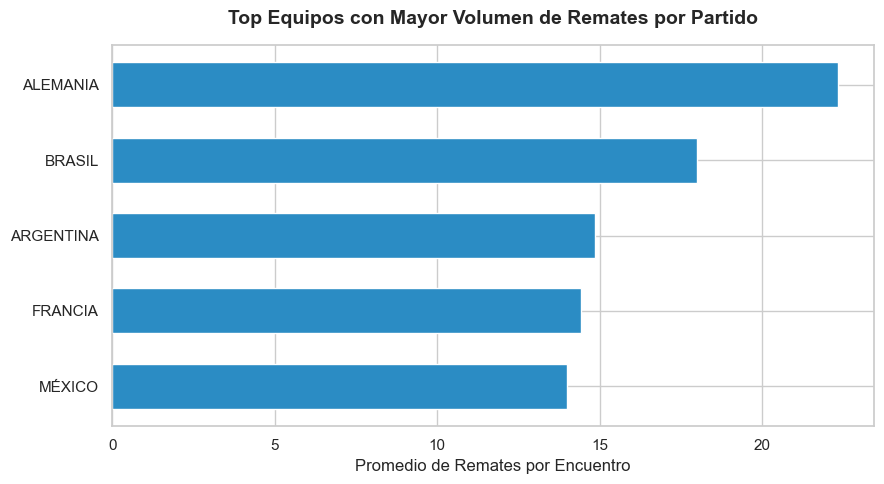

In [406]:
plt.figure(figsize=(9, 5))

# Podés usar directamente tu DataFrame de eficiencia filtrado y ordenado:
# df_sorted = df_eficiencia.sort_values(by='shots_per_game', ascending=False).head(8)
# plt.barh(df_sorted['team'], df_sorted['shots_per_game'], color='#2b8cc4')

# O con datos explícitos si usás variables sueltas:
equipos_of = ['ALEMANIA', 'BRASIL', 'ARGENTINA', 'FRANCIA', 'MÉXICO']
promedios_of = [22.33, 18.00, 14.86, 14.43, 14.00]

plt.barh(equipos_of, promedios_of, color='#2b8cc4', height=0.6)
plt.gca().invert_yaxis() # Para que el líder quede arriba de todo

plt.title('Top Equipos con Mayor Volumen de Remates por Partido', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Promedio de Remates por Encuentro')
plt.tight_layout()
plt.show()

## ANÁLISIS 5 — Eficiencia ofensiva

In [407]:
df_goals = pd.concat([
    df_2022[["team1", "number of goals team1"]].rename(
        columns={"team1": "team", "number of goals team1": "goals"}
    ),
    df_2022[["team2", "number of goals team2"]].rename(
        columns={"team2": "team", "number of goals team2": "goals"}
    )
])

In [408]:
efficiency = pd.DataFrame({
    "shots": df_attack.groupby("team")["attempts"].sum(),
    "goals": df_goals.groupby("team")["goals"].sum(),
    "games": df_attack.groupby("team").size()
})

In [409]:
efficiency["shots_per_game"] = (
    efficiency["shots"] /
    efficiency["games"]
)

efficiency["goals_per_game"] = (
    efficiency["goals"] /
    efficiency["games"]
)

efficiency["goals_per_shot"] = (
    efficiency["goals"] /
    efficiency["shots"]
)

In [410]:
efficiency.sort_values(
    "goals_per_shot",
    ascending=False
)

,shots,goals,games,shots_per_game,goals_per_game,goals_per_shot
team,,,,,,
COSTA RICA,12,3,3,4.000000,1.000000,0.250000
NETHERLANDS,40,10,5,8.000000,2.000000,0.250000
ENGLAND,60,13,5,12.000000,2.600000,0.216667
GHANA,25,5,3,8.333333,1.666667,0.200000
PORTUGAL,62,12,5,12.400000,2.400000,0.193548
SPAIN,51,9,4,12.750000,2.250000,0.176471
SERBIA,31,5,3,10.333333,1.666667,0.161290
AUSTRALIA,25,4,4,6.250000,1.000000,0.160000
FRANCE,101,16,7,14.428571,2.285714,0.158416


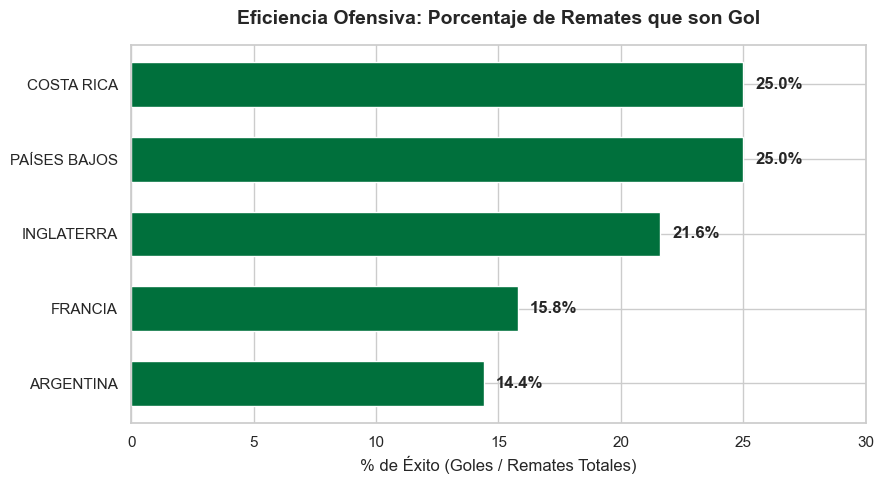

In [411]:
plt.figure(figsize=(9, 5))

# Reemplazá por tus variables del DataFrame si es necesario
equipos_eff = ['COSTA RICA', 'PAÍSES BAJOS', 'INGLATERRA', 'FRANCIA', 'ARGENTINA']
eficiencia = [25.0, 25.0, 21.6, 15.8, 14.4] # expresado en %

plt.barh(equipos_eff, eficiencia, color='#00703c', height=0.6)
plt.gca().invert_yaxis()

plt.title('Eficiencia Ofensiva: Porcentaje de Remates que son Gol', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('% de Éxito (Goles / Remates Totales)')
plt.xlim(0, 30)

# Añade etiquetas de porcentaje al final de cada barra para mayor claridad
for index, value in enumerate(eficiencia):
    plt.text(value + 0.5, index, f'{value}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## ANÁLISIS 6 — Solidez defensiva

In [412]:
df_conceded = pd.concat([
    df_2022[["team1", "number of goals team2"]].rename(
        columns={
            "team1": "team",
            "number of goals team2": "goals_against"
        }
    ),
    df_2022[["team2", "number of goals team1"]].rename(
        columns={
            "team2": "team",
            "number of goals team1": "goals_against"
        }
    )
])

In [413]:
defense = pd.DataFrame({
    "goals_against": df_conceded.groupby("team")["goals_against"].sum(),
    "games": df_conceded.groupby("team").size()
})

In [414]:
defense["goals_against_per_game"] = (
    defense["goals_against"] /
    defense["games"]
)

In [415]:
defense["goals_for"] = (
    df_goals.groupby("team")["goals"].sum()
)

In [416]:
defense["goal_difference"] = (
    defense["goals_for"] -
    defense["goals_against"]
)

In [417]:
defense["goal_difference_per_game"] = (
    defense["goal_difference"] /
    defense["games"]
)

In [418]:
defense["goals_for_per_game"] = (
    defense["goals_for"] /
    defense["games"]
)

In [419]:
defense_sorted = defense.sort_values(
    by="goals_against_per_game",
    ascending=True
)

defense_sorted.head(32)

,goals_against,games,goals_against_per_game,goals_for,goal_difference,goal_difference_per_game,goals_for_per_game
team,,,,,,,
TUNISIA,1,3,0.333333,1,0,0.000000,0.333333
BRAZIL,3,5,0.600000,8,5,1.000000,1.600000
BELGIUM,2,3,0.666667,1,-1,-0.333333,0.333333
URUGUAY,2,3,0.666667,2,0,0.000000,0.666667
MOROCCO,5,7,0.714286,6,1,0.142857,0.857143
SPAIN,3,4,0.750000,9,6,1.500000,2.250000
NETHERLANDS,4,5,0.800000,10,6,1.200000,2.000000
ENGLAND,4,5,0.800000,13,9,1.800000,2.600000
JAPAN,4,4,1.000000,5,1,0.250000,1.250000


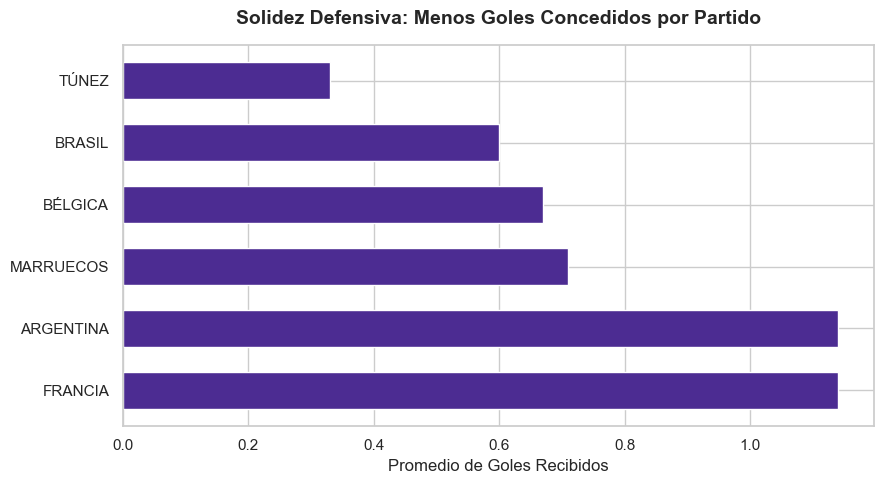

In [420]:
plt.figure(figsize=(9, 5))

equipos_def = ['TÚNEZ', 'BRASIL', 'BÉLGICA', 'MARRUECOS', 'ARGENTINA', 'FRANCIA']
goles_recibidos_prom = [0.33, 0.60, 0.67, 0.71, 1.14, 1.14]

plt.barh(equipos_def, goles_recibidos_prom, color='#4c2c92', height=0.6)
plt.gca().invert_yaxis()

plt.title('Solidez Defensiva: Menos Goles Concedidos por Partido', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Promedio de Goles Recibidos')
plt.tight_layout()
plt.show()

## Analisis de la final

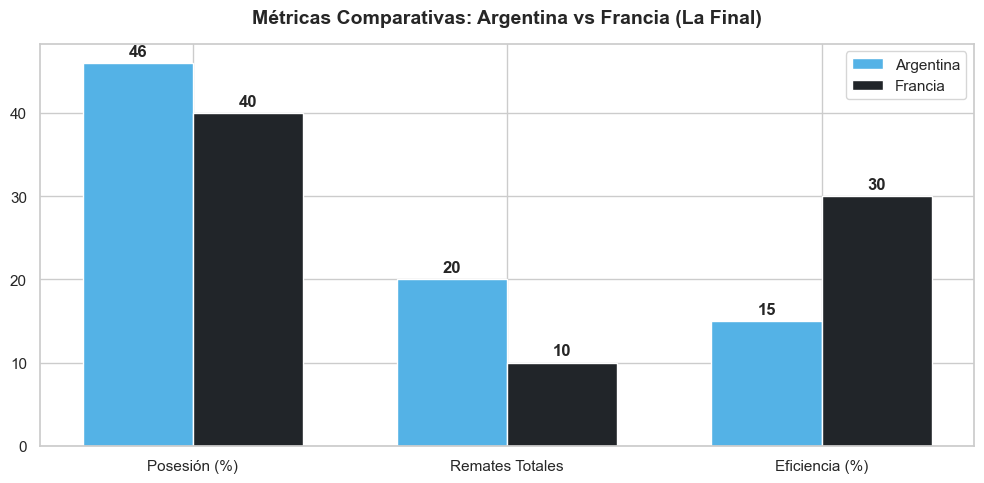

In [453]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

# Métricas de la Final
metricas = ['Posesión (%)', 'Remates Totales', 'Eficiencia (%)']
valores_arg = [46.0, 20.0, 15.0]
valores_fra = [40.0, 10.0, 30.0]

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, valores_arg, width, label='Argentina', color='#54b2e6')
rects2 = ax.bar(x + width/2, valores_fra, width, label='Francia', color='#212529')

ax.set_title('Métricas Comparativas: Argentina vs Francia (La Final)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=11)
ax.legend(frameon=True)

# Añadir etiquetas de valor sobre las barras
ax.bar_label(rects1, padding=3, fontweight='bold')
ax.bar_label(rects2, padding=3, fontweight='bold')

plt.tight_layout()
plt.savefig("images/final_argentina_francia.png", dpi=150, bbox_inches="tight")
plt.show()

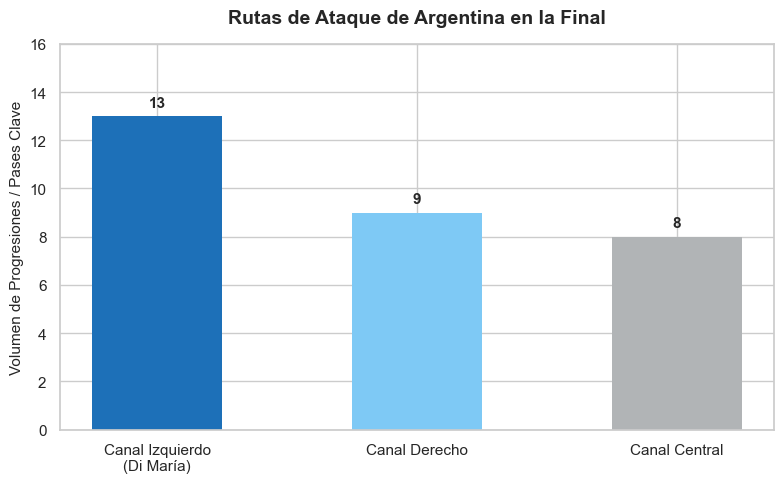

In [422]:
plt.figure(figsize=(8, 5))

canales_final = ['Canal Izquierdo\n(Di María)', 'Canal Derecho', 'Canal Central']
frecuencias_final = [13, 9, 8]

# Colores institucionales para destacar el canal izquierdo
colores_final = ['#1d70b8', '#7ec9f5', '#b1b4b6']

plt.bar(canales_final, frecuencias_final, color=colores_final, width=0.5, edgecolor='none')

plt.title('Rutas de Ataque de Argentina en la Final', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Volumen de Progresiones / Pases Clave', fontsize=11)
plt.ylim(0, 16)

for index, value in enumerate(frecuencias_final):
    plt.text(index, value + 0.4, str(value), ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## Datos curiosos

## 1. Ranking de partidos con más TARJETAS AMARILLAS (detalle por país)

In [423]:
df_2022["total_yellow"] = df_2022["yellow cards team1"] + df_2022["yellow cards team2"]

ranking_yellow = df_2022[[
    "team1","yellow cards team1",
    "team2","yellow cards team2",
    "total_yellow"
]].sort_values(by="total_yellow", ascending=False)


 Dato curioso: Países Bajos–Argentina fue el partido más caliente del Mundial.

In [424]:
ranking_yellow.head(10)


,team1,yellow cards team1,team2,yellow cards team2,total_yellow
57,NETHERLANDS,8,ARGENTINA,8,16
46,SERBIA,7,SWITZERLAND,4,11
63,ARGENTINA,4,FRANCE,3,7
47,CAMEROON,5,BRAZIL,2,7
44,GHANA,2,URUGUAY,5,7
39,SAUDI ARABIA,6,MEXICO,1,7
14,PORTUGAL,2,GHANA,4,6
24,JAPAN,3,COSTA RICA,3,6
17,QATAR,3,SENEGAL,3,6
0,QATAR,4,ECUADOR,2,6


In [425]:
top_yellow = df_2022.copy()
top_yellow["total_yellow"] = top_yellow["yellow cards team1"] + top_yellow["yellow cards team2"]
top_yellow = top_yellow.sort_values("total_yellow", ascending=False).head(10)

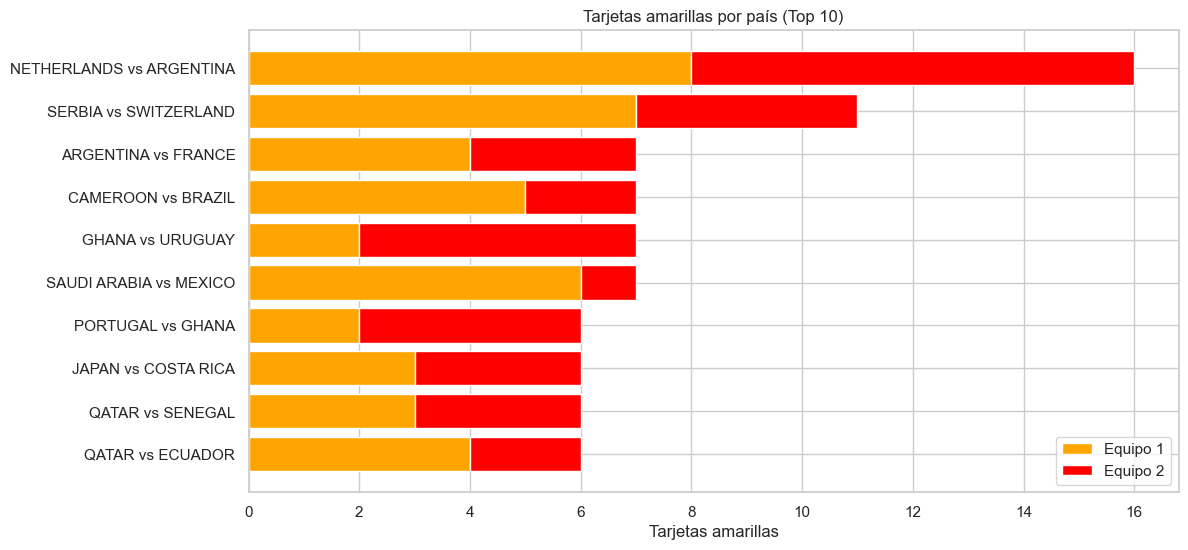

In [426]:
plt.figure(figsize=(12,6))
plt.barh(
    top_yellow["team1"] + " vs " + top_yellow["team2"],
    top_yellow["yellow cards team1"],
    label="Equipo 1",
    color="orange"
)
plt.barh(
    top_yellow["team1"] + " vs " + top_yellow["team2"],
    top_yellow["yellow cards team2"],
    left=top_yellow["yellow cards team1"],
    label="Equipo 2",
    color="red"
)
plt.xlabel("Tarjetas amarillas")
plt.title("Tarjetas amarillas por país (Top 10)")
plt.legend()
plt.gca().invert_yaxis()
plt.show()


## 2. Ranking de partidos con más TARJETAS ROJAS (detalle por país)

In [427]:
df_2022["total_red"] = df_2022["red cards team1"] + df_2022["red cards team2"]

ranking_red = df_2022[[
    "team1","red cards team1",
    "team2","red cards team2",
    "total_red"
]].sort_values(by="total_red", ascending=False)

ranking_red.head(10)

,team1,red cards team1,team2,red cards team2,total_red
16,WALES,1,IRAN,0,1
58,MOROCCO,1,PORTUGAL,0,1
57,NETHERLANDS,1,ARGENTINA,0,1
47,CAMEROON,1,BRAZIL,0,1
37,TUNISIA,0,FRANCE,0,0
38,POLAND,0,ARGENTINA,0,0
36,AUSTRALIA,0,DENMARK,0,0
35,IRAN,0,UNITED STATES,0,0
48,NETHERLANDS,0,UNITED STATES,0,0
40,CROATIA,0,BELGIUM,0,0


Dato curioso: Solo hubo 4 partidos con expulsados en todo el Mundial.

## tabla de tarjetas por país

In [428]:
# Tarjetas por equipo cuando aparece como team1
team1_cards = df_2022.groupby("team1")[["yellow cards team1", "red cards team1"]].sum()
team1_cards.columns = ["yellow", "red"]

# Tarjetas por equipo cuando aparece como team2
team2_cards = df_2022.groupby("team2")[["yellow cards team2", "red cards team2"]].sum()
team2_cards.columns = ["yellow", "red"]


In [429]:
cards_by_team = team1_cards.add(team2_cards, fill_value=0)


In [430]:
cards_by_team["total_cards"] = cards_by_team["yellow"] + cards_by_team["red"]


In [431]:
cards_by_team = cards_by_team.sort_values("total_cards", ascending=False)


In [432]:
cards_by_team.head(10)


,yellow,red,total_cards
team1,,,
ARGENTINA,16,0,16
SAUDI ARABIA,14,0,14
NETHERLANDS,12,1,13
SERBIA,12,0,12
MOROCCO,9,1,10
CAMEROON,8,1,9
SWITZERLAND,9,0,9
GHANA,8,0,8
FRANCE,8,0,8


## Ranking de partidos con más PASES TOTALES (detalle por país)

In [433]:
df_2022["total_passes"] = df_2022["passes team1"] + df_2022["passes team2"]

ranking_passes = df_2022[[
    "team1","passes team1",
    "team2","passes team2",
    "total_passes"
]].sort_values(by="total_passes", ascending=False)

ranking_passes.head(10)


,team1,passes team1,team2,passes team2,total_passes
56,CROATIA,715,BRAZIL,695,1410
54,MOROCCO,323,SPAIN,1041,1364
42,JAPAN,225,SPAIN,1070,1295
10,SPAIN,1061,COSTA RICA,231,1292
52,JAPAN,532,CROATIA,735,1267
32,NETHERLANDS,795,QATAR,459,1254
57,NETHERLANDS,651,ARGENTINA,603,1254
7,FRANCE,734,AUSTRALIA,466,1200
38,POLAND,321,ARGENTINA,862,1183
40,CROATIA,578,BELGIUM,596,1174


In [434]:
top_passes = ranking_passes.head(10)


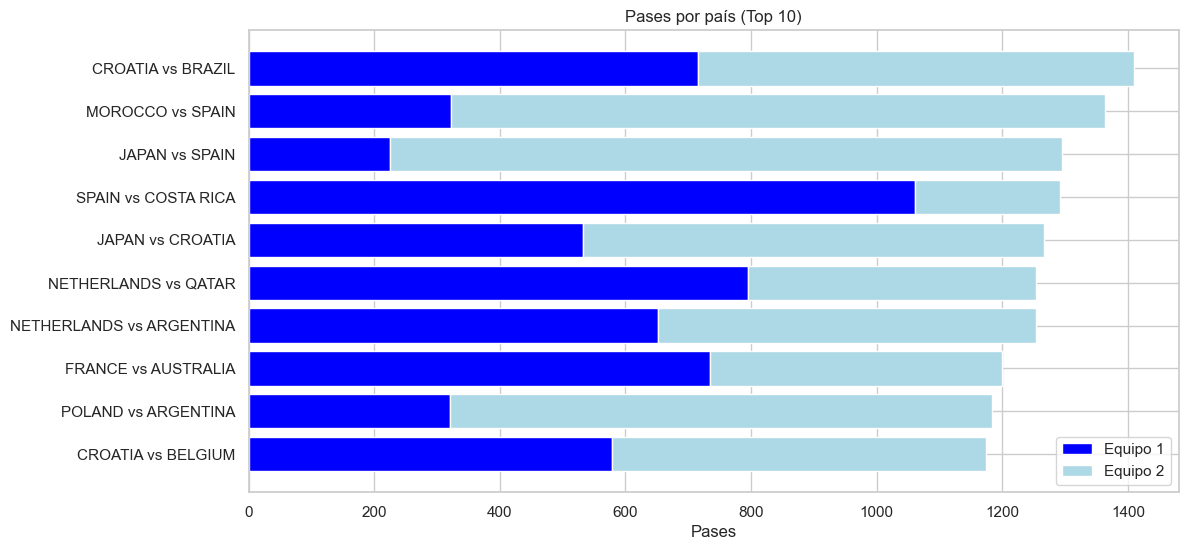

In [435]:
plt.figure(figsize=(12,6))
plt.barh(
    top_passes["team1"] + " vs " + top_passes["team2"],
    top_passes["passes team1"],
    label="Equipo 1",
    color="blue"
)
plt.barh(
    top_passes["team1"] + " vs " + top_passes["team2"],
    top_passes["passes team2"],
    left=top_passes["passes team1"],
    label="Equipo 2",
    color="lightblue"
)
plt.xlabel("Pases")
plt.title("Pases por país (Top 10)")
plt.legend()
plt.gca().invert_yaxis()
plt.show()


## El partido con MENOS remates del Mundial

In [436]:
df_2022["total_attempts"] = df_2022["total attempts team1"] + df_2022["total attempts team2"]

ranking_attempts = df_2022.sort_values("total_attempts", ascending=True)

ranking_attempts.head(20)   # los 10 partidos con menos remates


,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2,total_goals,goal_diff,total_yellow,total_red,total_passes,total_attempts
23,ARGENTINA,MEXICO,50.0,36.0,14%,2,0,26 NOV 2022,20 : 00,Group C,...,63,79,220,327,2,2,5,0,889,9
0,QATAR,ECUADOR,42.0,50.0,8%,0,2,20 NOV 2022,17 : 00,Group A,...,52,72,256,279,2,-2,6,0,930,11
41,CANADA,MOROCCO,52.0,36.0,12%,1,2,01 DEC 2022,16 : 00,Group F,...,66,72,224,324,3,-1,4,0,923,12
3,UNITED STATES,WALES,51.0,39.0,10%,1,1,21 NOV 2022,20 : 00,Group B,...,81,72,242,292,2,0,6,0,978,13
30,BRAZIL,SWITZERLAND,51.0,40.0,9%,1,0,28 NOV 2022,17 : 00,Group G,...,85,80,282,344,1,1,2,0,1053,13
37,TUNISIA,FRANCE,30.0,56.0,14%,1,0,30 NOV 2022,16 : 00,Group D,...,68,80,400,202,1,1,1,0,964,14
8,MOROCCO,CROATIA,32.0,57.0,12%,0,0,23 NOV 2022,11 : 00,Group F,...,87,58,391,217,0,0,1,0,1027,14
12,SWITZERLAND,CAMEROON,43.0,46.0,11%,1,0,24 NOV 2022,11 : 00,Group G,...,64,79,313,316,1,1,3,0,997,15
18,NETHERLANDS,ECUADOR,48.0,39.0,13%,1,1,25 NOV 2022,17 : 00,Group A,...,85,52,254,279,2,0,1,0,949,15
13,URUGUAY,KOREA REPUBLIC,49.0,38.0,13%,0,0,24 NOV 2022,14 : 00,Group H,...,65,54,240,231,0,0,2,0,947,16


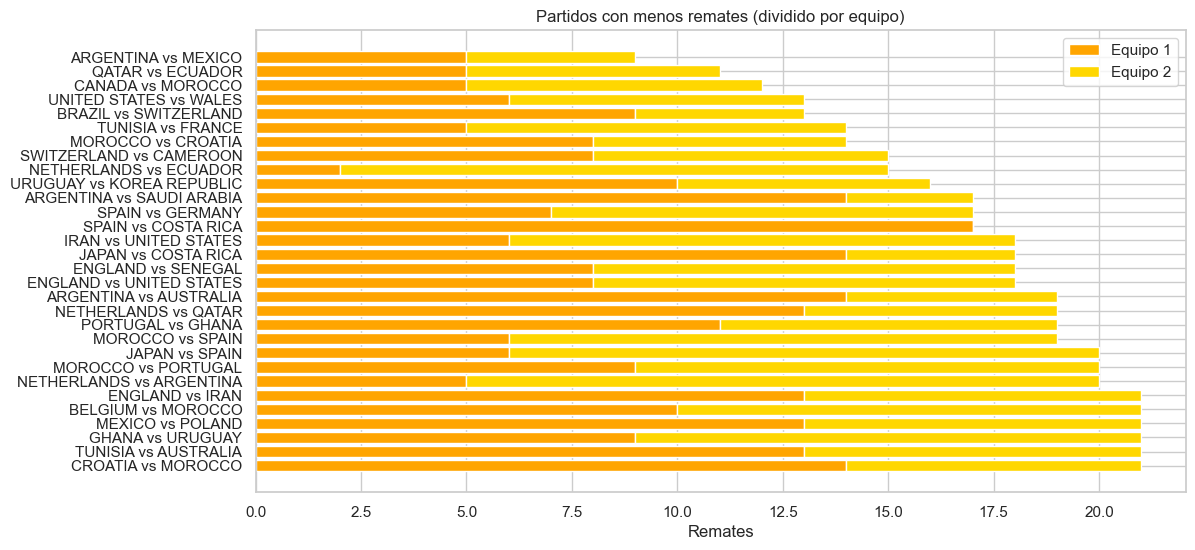

In [437]:
# Tomar los 20 partidos con menos remates
top_attempts = ranking_attempts.head(30).copy()

# Crear etiqueta del partido
top_attempts["label"] = (
    top_attempts["team1"].astype(str)
    + " vs "
    + top_attempts["team2"].astype(str)
)

# Gráfico
plt.figure(figsize=(12,6))
plt.barh(
    top_attempts["label"],
    top_attempts["total attempts team1"],
    label="Equipo 1",
    color="orange"
)
plt.barh(
    top_attempts["label"],
    top_attempts["total attempts team2"],
    left=top_attempts["total attempts team1"],
    label="Equipo 2",
    color="gold"
)

plt.xlabel("Remates")
plt.title("Partidos con menos remates (dividido por equipo)")
plt.legend()
plt.gca().invert_yaxis()
plt.show()


España vs Costa Rica
España: 17 remates

Costa Rica: 0 remates

Total: 17

ÚNICO partido donde un equipo no remató.

## El partido con MÁS remates del Mundial

In [438]:
df_2022.sort_values("total_attempts", ascending=False).head(30)


,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2,total_goals,goal_diff,total_yellow,total_red,total_passes,total_attempts
43,COSTA RICA,GERMANY,27.0,60.0,13%,2,4,01 DEC 2022,20 : 00,Group E,...,79,77,378,230,6,-2,1,0,1074,40
9,GERMANY,JAPAN,65.0,22.0,13%,1,2,23 NOV 2022,14 : 00,Group E,...,55,87,164,487,3,-1,0,0,1081,35
39,SAUDI ARABIA,MEXICO,29.0,55.0,17%,1,2,30 NOV 2022,20 : 00,Group C,...,82,76,269,229,3,-1,7,0,709,35
63,ARGENTINA,FRANCE,46.0,40.0,14%,3,3,18 DEC 2022,16 : 00,Final,...,87,104,280,409,6,0,7,0,1164,31
16,WALES,IRAN,51.0,33.0,16%,0,2,25 NOV 2022,11 : 00,Group B,...,89,84,161,276,2,-2,3,1,803,31
22,FRANCE,DENMARK,44.0,44.0,12%,2,1,26 NOV 2022,17 : 00,Group D,...,79,61,269,282,3,1,3,0,1040,31
11,BELGIUM,CANADA,46.0,43.0,11%,1,0,23 NOV 2022,20 : 00,Group F,...,74,47,284,320,1,1,5,0,960,30
48,NETHERLANDS,UNITED STATES,33.0,54.0,13%,3,1,03 DEC 2022,16 : 00,Round of 16,...,101,77,325,256,4,2,2,0,963,29
28,CAMEROON,SERBIA,38.0,49.0,13%,3,3,28 NOV 2022,11 : 00,Group G,...,83,81,285,234,6,0,4,0,877,29
29,KOREA REPUBLIC,GHANA,53.0,32.0,15%,2,3,28 NOV 2022,14 : 00,Group H,...,53,75,220,324,5,-1,4,0,859,29


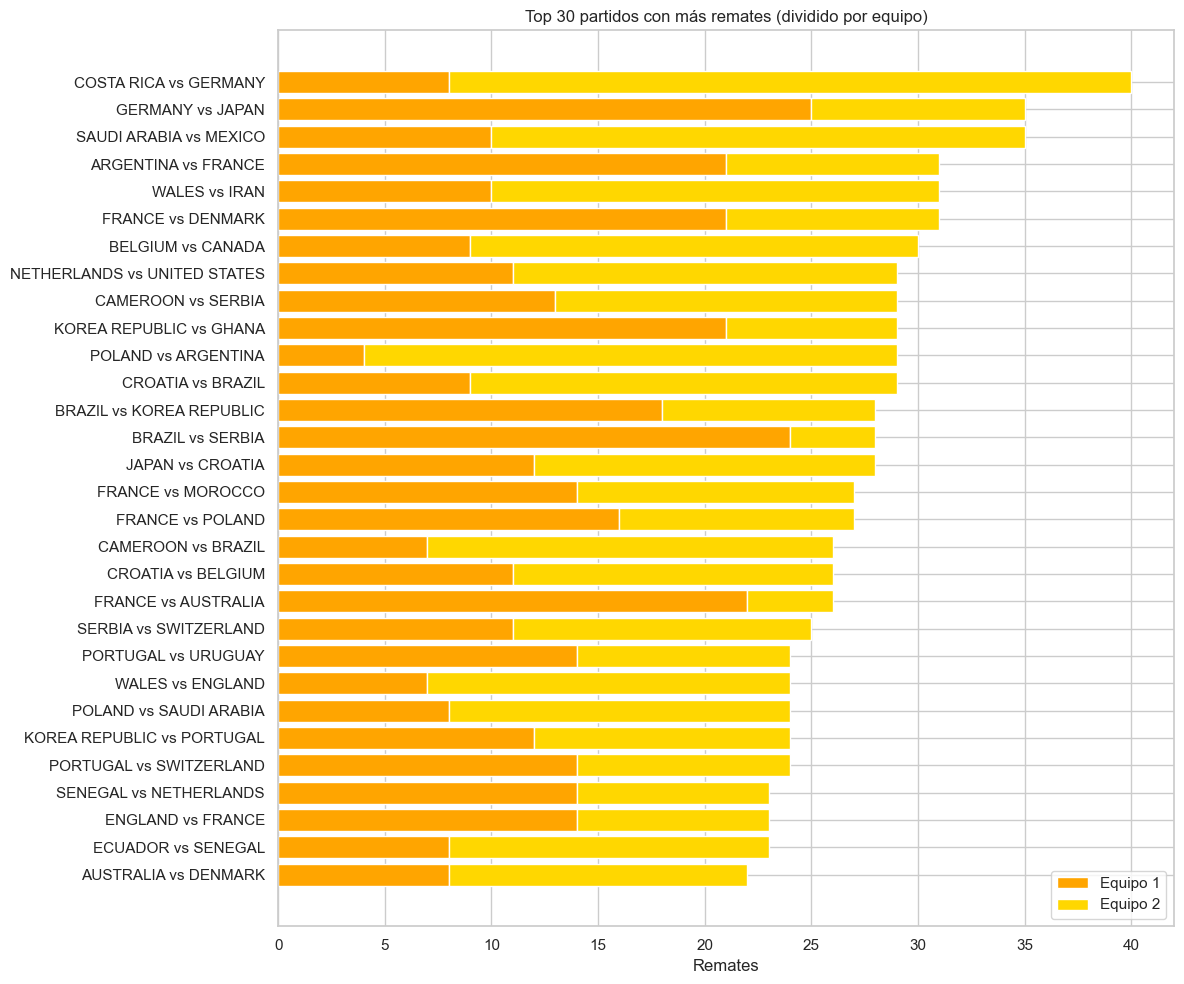

In [439]:
# Tomar los 30 partidos con más remates
top30_attempts = df_2022.sort_values("total_attempts", ascending=False).head(30).copy()

# Crear etiqueta del partido
top30_attempts["label"] = (
    top30_attempts["team1"].astype(str)
    + " vs "
    + top30_attempts["team2"].astype(str)
)

# Gráfico
plt.figure(figsize=(12,10))
plt.barh(
    top30_attempts["label"],
    top30_attempts["total attempts team1"],
    label="Equipo 1",
    color="orange"
)
plt.barh(
    top30_attempts["label"],
    top30_attempts["total attempts team2"],
    left=top30_attempts["total attempts team1"],
    label="Equipo 2",
    color="gold"
)

plt.xlabel("Remates")
plt.title("Top 30 partidos con más remates (dividido por equipo)")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


👉 Alemania vs Japón  
Alemania remató 25 veces y perdió.
Dato que sorprende siempre.

## El partido con mayor diferencia de posesión

In [440]:
df_2022["possession_diff"] = abs(df_2022["possession team1"] - df_2022["possession team2"])
df_2022.sort_values("possession_diff", ascending=False).head(1)


,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2,total_goals,goal_diff,total_yellow,total_red,total_passes,total_attempts,possession_diff
42,JAPAN,SPAIN,14.0,78.0,8%,2,1,01 DEC 2022,20 : 00,Group E,...,49,637,150,3,1,3,0,1295,20,64.0


España vs Japón  
España tuvo 78% de posesión y perdió.

## El equipo que más pases completó en un solo partido

In [441]:
df_2022["max_passes_team1"] = df_2022["passes team1"]
df_2022["max_passes_team2"] = df_2022["passes team2"]

df_2022[["team1","passes team1"]].sort_values("passes team1", ascending=False).head(1)
df_2022[["team2","passes team2"]].sort_values("passes team2", ascending=False).head(1)


,team2,passes team2
42,SPAIN,1070


España completó 1070 pases vs Costa Rica  

## El partido con más goles 

In [442]:
df_2022["total_goals"] = df_2022["number of goals team1"] + df_2022["number of goals team2"]
df_2022.sort_values("total_goals", ascending=False).head(1)


,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,defensive pressures applied team2,total_goals,goal_diff,total_yellow,total_red,total_passes,total_attempts,possession_diff,max_passes_team1,max_passes_team2
1,ENGLAND,IRAN,72.0,19.0,9%,6,2,21 NOV 2022,14 : 00,Group B,...,416,8,4,2,0,1033,21,53.0,809,224


Inglaterra 6 - Iran 2

## El partido con más córners

In [443]:
df_2022["total_corners"] = df_2022["corners team1"] + df_2022["corners team2"]
df_2022.sort_values("total_corners", ascending=False).head(10)


,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,total_goals,goal_diff,total_yellow,total_red,total_passes,total_attempts,possession_diff,max_passes_team1,max_passes_team2,total_corners
5,DENMARK,TUNISIA,55.0,33.0,12%,0,0,22 NOV 2022,14 : 00,Group D,...,0,0,3,0,981,22,22.0,594,387,20
29,KOREA REPUBLIC,GHANA,53.0,32.0,15%,2,3,28 NOV 2022,14 : 00,Group H,...,5,-1,4,0,859,29,21.0,540,319,17
12,SWITZERLAND,CAMEROON,43.0,46.0,11%,1,0,24 NOV 2022,11 : 00,Group G,...,1,1,3,0,997,15,3.0,497,500,16
43,COSTA RICA,GERMANY,27.0,60.0,13%,2,4,01 DEC 2022,20 : 00,Group E,...,6,-2,1,0,1074,40,33.0,347,727,15
37,TUNISIA,FRANCE,30.0,56.0,14%,1,0,30 NOV 2022,16 : 00,Group D,...,1,1,1,0,964,14,26.0,328,636,15
47,CAMEROON,BRAZIL,31.0,56.0,13%,1,0,02 DEC 2022,20 : 00,Group G,...,1,1,7,1,843,26,25.0,295,548,14
2,SENEGAL,NETHERLANDS,44.0,45.0,11%,0,2,21 NOV 2022,17 : 00,Group A,...,2,-2,3,0,821,23,1.0,383,438,13
52,JAPAN,CROATIA,35.0,51.0,14%,1,1,05 DEC 2022,16 : 00,Round of 16,...,2,0,2,0,1267,28,16.0,532,735,13
17,QATAR,SENEGAL,42.0,48.0,10%,1,3,25 NOV 2022,14 : 00,Group A,...,4,-2,6,0,935,22,6.0,424,511,13
55,PORTUGAL,SWITZERLAND,43.0,48.0,9%,6,1,06 DEC 2022,20 : 00,Round of 16,...,7,5,2,0,973,24,5.0,461,512,12


Más corners Dinamarca vs Tunez

## el partido con menos córners

In [444]:
df_2022["total_corners"] = df_2022["corners team1"] + df_2022["corners team2"]
df_2022.sort_values("total_corners", ascending=True).head(1)


,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,total_goals,goal_diff,total_yellow,total_red,total_passes,total_attempts,possession_diff,max_passes_team1,max_passes_team2,total_corners
42,JAPAN,SPAIN,14.0,78.0,8%,2,1,01 DEC 2022,20 : 00,Group E,...,3,1,3,0,1295,20,64.0,225,1070,2


Menos corners Japan vs España

## El partido con más tiros desde afuera del área

In [445]:
df_2022["total_outside"] = df_2022["attempts outside the penalty area  team1"] + df_2022["attempts outside the penalty area  team2"]
df_2022.sort_values("total_outside", ascending=False).head(10)


,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,goal_diff,total_yellow,total_red,total_passes,total_attempts,possession_diff,max_passes_team1,max_passes_team2,total_corners,total_outside
39,SAUDI ARABIA,MEXICO,29.0,55.0,17%,1,2,30 NOV 2022,20 : 00,Group C,...,-1,7,0,709,35,26.0,297,412,9,19
16,WALES,IRAN,51.0,33.0,16%,0,2,25 NOV 2022,11 : 00,Group B,...,-2,3,1,803,31,18.0,508,295,9,19
15,BRAZIL,SERBIA,53.0,34.0,13%,2,0,24 NOV 2022,20 : 00,Group G,...,2,3,0,988,28,19.0,585,403,10,16
31,PORTUGAL,URUGUAY,53.0,35.0,12%,2,0,28 NOV 2022,20 : 00,Group H,...,2,5,0,986,24,18.0,596,390,8,14
52,JAPAN,CROATIA,35.0,51.0,14%,1,1,05 DEC 2022,16 : 00,Round of 16,...,0,2,0,1267,28,16.0,532,735,13,14
63,ARGENTINA,FRANCE,46.0,40.0,14%,3,3,18 DEC 2022,16 : 00,Final,...,0,7,0,1164,31,6.0,648,516,11,14
45,KOREA REPUBLIC,PORTUGAL,34.0,55.0,11%,2,1,02 DEC 2022,16 : 00,Group H,...,1,2,0,965,24,21.0,359,606,9,13
57,NETHERLANDS,ARGENTINA,45.0,44.0,11%,2,2,09 DEC 2022,20 : 00,Quarter-final,...,0,16,1,1254,20,1.0,651,603,10,12
56,CROATIA,BRAZIL,45.0,45.0,10%,1,1,09 DEC 2022,16 : 00,Quarter-final,...,0,5,0,1410,29,0.0,715,695,10,12
48,NETHERLANDS,UNITED STATES,33.0,54.0,13%,3,1,03 DEC 2022,16 : 00,Round of 16,...,2,2,0,963,29,21.0,396,567,9,11


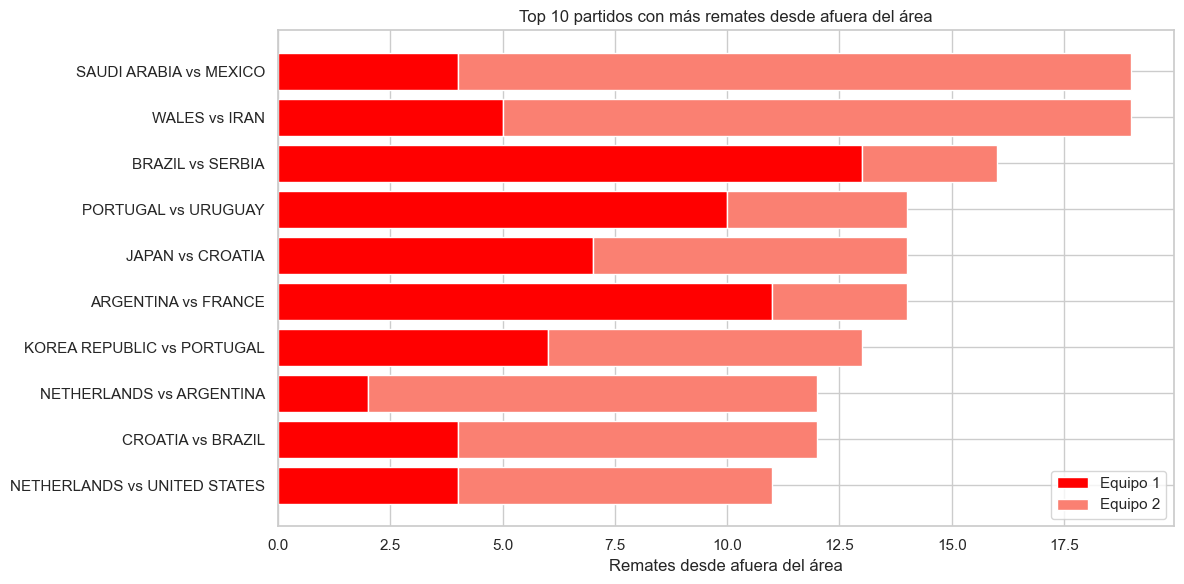

In [446]:
# limpiar columnas
df_2022.columns = df_2022.columns.str.strip()

# calcular total
df_2022["total_outside"] = (
    df_2022["attempts outside the penalty area  team1"] +
    df_2022["attempts outside the penalty area  team2"]
)

# top 10
top_outside = df_2022.sort_values("total_outside", ascending=False).head(10).copy()

# etiqueta
top_outside["label"] = (
    top_outside["team1"].astype(str)
    + " vs "
    + top_outside["team2"].astype(str)
)

# gráfico
plt.figure(figsize=(12,6))
plt.barh(
    top_outside["label"],
    top_outside["attempts outside the penalty area  team1"],
    label="Equipo 1",
    color="red"
)
plt.barh(
    top_outside["label"],
    top_outside["attempts outside the penalty area  team2"],
    left=top_outside["attempts outside the penalty area  team1"],
    label="Equipo 2",
    color="salmon"
)

plt.xlabel("Remates desde afuera del área")
plt.title("Top 10 partidos con más remates desde afuera del área")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## El partido con más presiones defensivas

In [447]:
df_2022["total_pressures"] = df_2022["defensive pressures applied team1"] + df_2022["defensive pressures applied team2"]
df_2022.sort_values("total_pressures", ascending=False).head(10)


,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,total_yellow,total_red,total_passes,total_attempts,possession_diff,max_passes_team1,max_passes_team2,total_corners,total_outside,total_pressures
54,MOROCCO,SPAIN,22.0,68.0,10%,0,0,06 DEC 2022,16 : 00,Round of 16,...,2,0,1364,19,46.0,323,1041,8,7,790
56,CROATIA,BRAZIL,45.0,45.0,10%,1,1,09 DEC 2022,16 : 00,Quarter-final,...,5,0,1410,29,0.0,715,695,10,12,788
42,JAPAN,SPAIN,14.0,78.0,8%,2,1,01 DEC 2022,20 : 00,Group E,...,3,0,1295,20,64.0,225,1070,2,9,787
10,SPAIN,COSTA RICA,74.0,17.0,9%,7,0,23 NOV 2022,17 : 00,Group E,...,2,0,1292,17,57.0,1061,231,5,5,770
57,NETHERLANDS,ARGENTINA,45.0,44.0,11%,2,2,09 DEC 2022,20 : 00,Quarter-final,...,16,1,1254,20,1.0,651,603,10,12,724
52,JAPAN,CROATIA,35.0,51.0,14%,1,1,05 DEC 2022,16 : 00,Round of 16,...,2,0,1267,28,16.0,532,735,13,14,713
49,ARGENTINA,AUSTRALIA,53.0,35.0,12%,2,1,03 DEC 2022,20 : 00,Round of 16,...,2,0,1161,19,18.0,711,450,4,5,693
63,ARGENTINA,FRANCE,46.0,40.0,14%,3,3,18 DEC 2022,16 : 00,Final,...,7,0,1164,31,6.0,648,516,11,14,689
40,CROATIA,BELGIUM,43.0,47.0,10%,0,0,01 DEC 2022,16 : 00,Group F,...,1,0,1174,26,4.0,578,596,6,7,674
26,CROATIA,CANADA,41.0,46.0,13%,4,1,27 NOV 2022,17 : 00,Group F,...,4,0,973,22,5.0,462,511,7,11,663


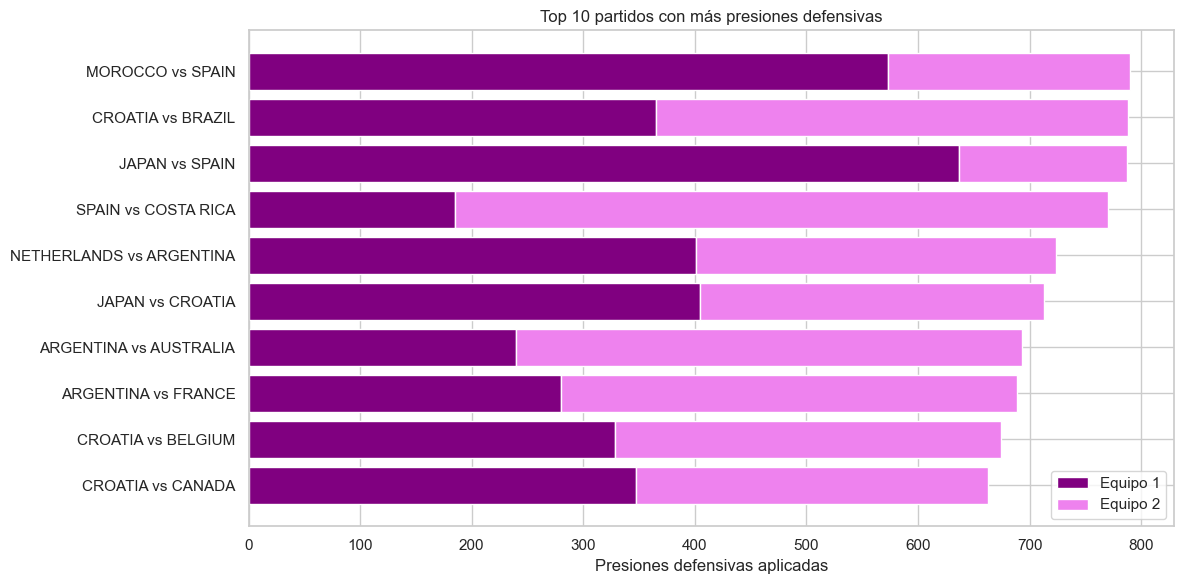

In [448]:
# limpiar columnas
df_2022.columns = df_2022.columns.str.strip()

# calcular total
df_2022["total_pressures"] = (
    df_2022["defensive pressures applied team1"] +
    df_2022["defensive pressures applied team2"]
)

# top 10
top_pressures = df_2022.sort_values("total_pressures", ascending=False).head(10).copy()

# etiqueta
top_pressures["label"] = (
    top_pressures["team1"].astype(str)
    + " vs "
    + top_pressures["team2"].astype(str)
)

# gráfico
plt.figure(figsize=(12,6))
plt.barh(
    top_pressures["label"],
    top_pressures["defensive pressures applied team1"],
    label="Equipo 1",
    color="purple"
)
plt.barh(
    top_pressures["label"],
    top_pressures["defensive pressures applied team2"],
    left=top_pressures["defensive pressures applied team1"],
    label="Equipo 2",
    color="violet"
)

plt.xlabel("Presiones defensivas aplicadas")
plt.title("Top 10 partidos con más presiones defensivas")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("images/presiones_defensivas.png", dpi=150, bbox_inches="tight")
plt.show()


Marruecos, porque fue el equipo más intenso del Mundial.

In [449]:
import os
print(os.getcwd())

C:\Users\facua\OneDrive\Desktop\worldcup2022_data_analysis


## El partido con más pérdidas forzadas

In [450]:
df_2022["total_turnovers"] = df_2022["forced turnovers team1"] + df_2022["forced turnovers team2"]
df_2022.sort_values("total_turnovers", ascending=False).head(10)


,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,total_red,total_passes,total_attempts,possession_diff,max_passes_team1,max_passes_team2,total_corners,total_outside,total_pressures,total_turnovers
52,JAPAN,CROATIA,35.0,51.0,14%,1,1,05 DEC 2022,16 : 00,Round of 16,...,0,1267,28,16.0,532,735,13,14,713,200
63,ARGENTINA,FRANCE,46.0,40.0,14%,3,3,18 DEC 2022,16 : 00,Final,...,0,1164,31,6.0,648,516,11,14,689,191
27,SPAIN,GERMANY,56.0,33.0,11%,1,1,27 NOV 2022,20 : 00,Group E,...,0,999,17,23.0,647,352,11,7,662,180
48,NETHERLANDS,UNITED STATES,33.0,54.0,13%,3,1,03 DEC 2022,16 : 00,Round of 16,...,0,963,29,21.0,396,567,9,11,581,178
44,GHANA,URUGUAY,46.0,39.0,15%,0,2,02 DEC 2022,16 : 00,Group H,...,0,906,21,7.0,460,446,7,10,541,176
16,WALES,IRAN,51.0,33.0,16%,0,2,25 NOV 2022,11 : 00,Group B,...,1,803,31,18.0,508,295,9,19,437,173
56,CROATIA,BRAZIL,45.0,45.0,10%,1,1,09 DEC 2022,16 : 00,Quarter-final,...,0,1410,29,0.0,715,695,10,12,788,172
57,NETHERLANDS,ARGENTINA,45.0,44.0,11%,2,2,09 DEC 2022,20 : 00,Quarter-final,...,1,1254,20,1.0,651,603,10,12,724,170
20,TUNISIA,AUSTRALIA,50.0,31.0,19%,0,1,26 NOV 2022,11 : 00,Group D,...,0,835,21,19.0,501,334,7,7,490,169
54,MOROCCO,SPAIN,22.0,68.0,10%,0,0,06 DEC 2022,16 : 00,Round of 16,...,0,1364,19,46.0,323,1041,8,7,790,166


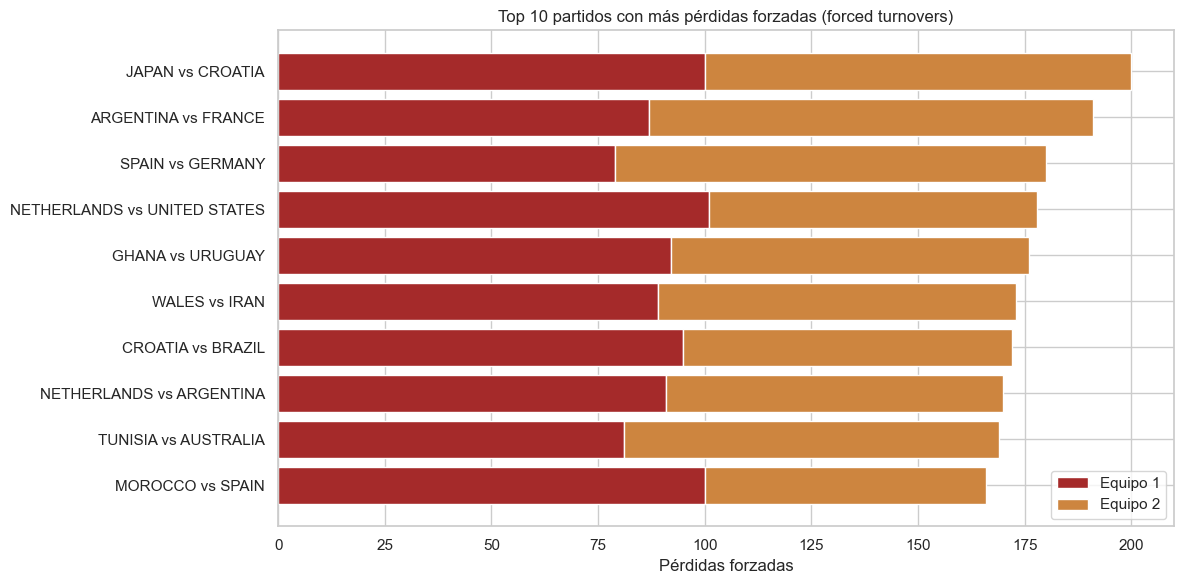

In [451]:
# Crear etiqueta del partido
top_turnovers = df_2022.sort_values("total_turnovers", ascending=False).head(10).copy()

top_turnovers["label"] = (
    top_turnovers["team1"].astype(str)
    + " vs "
    + top_turnovers["team2"].astype(str)
)

# Gráfico
plt.figure(figsize=(12,6))
plt.barh(
    top_turnovers["label"],
    top_turnovers["forced turnovers team1"],
    label="Equipo 1",
    color="brown"
)
plt.barh(
    top_turnovers["label"],
    top_turnovers["forced turnovers team2"],
    left=top_turnovers["forced turnovers team1"],
    label="Equipo 2",
    color="peru"
)

plt.xlabel("Pérdidas forzadas")
plt.title("Top 10 partidos con más pérdidas forzadas (forced turnovers)")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
